# 11 &middot; Mass Springs: from Hooke's Law to a Sagging Cable

The spring is the simplest elastic element there is: two point masses joined by
one edge. We start from its energy, watch Hooke's law fall out of a derivative,
add inertia and compare time integrators in *phase space*, then glue many springs
into a cable and let it sag under gravity.

| step | what we do |
|---|---|
| **1** | build the spring energy and collapse the spring &mdash; Hooke's law appears |
| **2** | add mass; march Forward / Backward Euler & BDF2; read the phase portrait |
| **3** | chain springs into a cable; sag it with and without inertia |

In [1]:
# --- make the *local* simkit (this repo) importable, ahead of any installed copy ---
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "..")))
%matplotlib inline
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import simkit
import simkit.energies as energies
from simkit.solvers import newton_solver
from simkit.integrators import backward_euler
import utils
os.makedirs("media", exist_ok=True)

## 1 &middot; The elastic energy of a single spring (Hooke's law)

A spring has endpoints \(x_i\) and \(x_j\). We build its energy in four small
steps, each throwing away information we do **not** want the energy to care about:

1. **edge vector** \(d = x_j - x_i\) &mdash; kills *translation* (sliding both
   nodes together leaves \(d\) unchanged);
2. **current length** \(l = \lVert d\rVert\) &mdash; kills *rotation* (only the
   distance matters);
3. **strain** \(l - l_0\) &mdash; how far we are from the rest length \(l_0\);
4. **energy** \(\psi = \tfrac{1}{2}\,k\,(l-l_0)^2\).

The stiffness is \(k = ym/l_0^2\); dividing by \(l_0^2\) makes the energy
mesh-independent. This \(\psi\) is exactly `mass_springs_energy_element_d`.
Differentiate once and the **force** drops out,
$$ f = -\frac{d\psi}{dl} = -k\,(l-l_0), $$
linear in the stretch and pointing back toward rest &mdash; that *is* Hooke's law,
derived from a quadratic energy rather than assumed.

rest length l0 = 1.000,  stiffness k = ym/l0^2 = 1.000


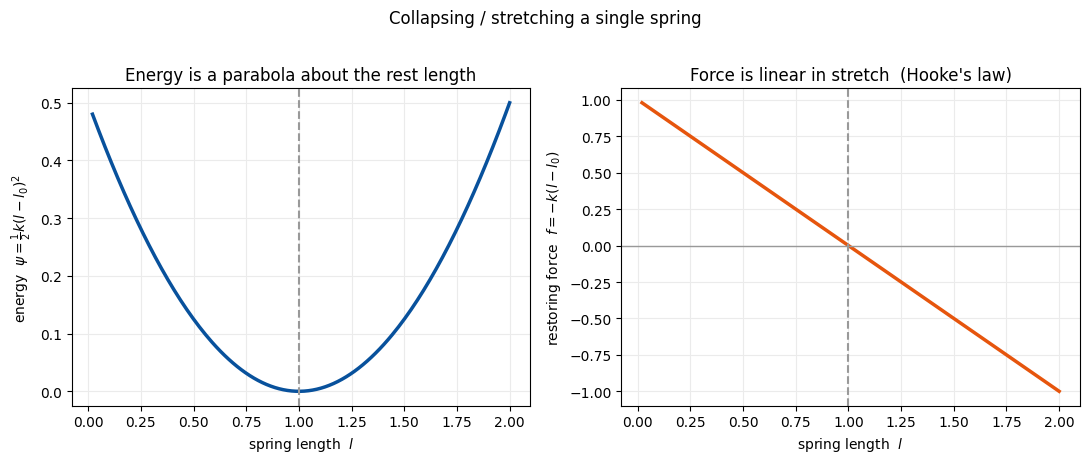

In [2]:
l0_val = 1.0
X = np.array([[0.0, 0.0], [l0_val, 0.0]])     # node 0 pinned at origin, node 1 at rest
E = np.array([[0, 1]])

ym  = np.array([[1.0]])                        # per-edge stiffness
vol = np.ones((1, 1))                          # one element, unit quadrature weight
l0  = simkit.edge_lengths(X, E).reshape(-1, 1)
k   = float((ym / l0 ** 2).flatten()[0])       # effective Hooke stiffness
print(f"rest length l0 = {l0[0,0]:.3f},  stiffness k = ym/l0^2 = {k:.3f}")

# energy + force as the spring is collapsed (l -> 0) and stretched (l -> 2 l0)
lengths = np.linspace(0.02, 2.0 * l0_val, 200)
d       = np.column_stack([lengths, np.zeros_like(lengths)])
psi     = energies.mass_springs_energy_element_d(d, ym, l0).flatten()
dpsi_dl = energies.mass_springs_gradient_element_d(d, ym, l0)[:, 0]   # = k (l - l0)
force   = -dpsi_dl                                                     # Hooke restoring force

fig, (ax_e, ax_f) = plt.subplots(1, 2, figsize=(11, 4.5))
ax_e.plot(lengths, psi, color=utils.SPRING_EDGE, lw=2.5)
ax_e.axvline(l0_val, color="0.6", ls="--", lw=1.5)
ax_e.set_xlabel("spring length  $l$"); ax_e.set_ylabel(r"energy  $\psi=\frac{1}{2}k(l-l_0)^2$")
ax_e.set_title("Energy is a parabola about the rest length"); ax_e.grid(True, color="0.92")
ax_f.plot(lengths, force, color=utils.SPRING_NODE, lw=2.5)
ax_f.axhline(0, color="0.6", lw=1.0); ax_f.axvline(l0_val, color="0.6", ls="--", lw=1.5)
ax_f.set_xlabel("spring length  $l$"); ax_f.set_ylabel(r"restoring force  $f=-k(l-l_0)$")
ax_f.set_title("Force is linear in stretch  (Hooke's law)"); ax_f.grid(True, color="0.92")
fig.suptitle("Collapsing / stretching a single spring", y=1.02); fig.tight_layout(); plt.show()

Now collapse and re-stretch the spring, revealing the energy curve in lock-step
so the quadratic well around \(l_0\) is unmistakable.


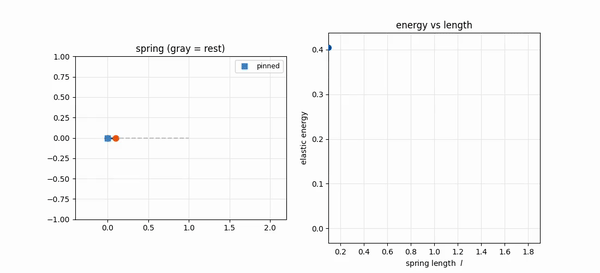

In [3]:
sweep  = np.concatenate([np.linspace(0.1, 1.9, 45), np.linspace(1.9, 0.1, 45)])
states = [np.array([[0.0, 0.0], [s, 0.0]]) for s in sweep]
psi_sweep = energies.mass_springs_energy_element_d(
    np.column_stack([sweep, np.zeros_like(sweep)]), ym, l0).flatten()
fig, anim = utils.animate_springs_energy(
    states, E, sweep, {"elastic": psi_sweep}, rest=X, lims=((-0.4, 2.2), (-1.0, 1.0)),
    xlabel="spring length  $l$", ylabel="elastic energy", scene_title="spring (gray = rest)",
    title="energy vs length", colors={"elastic": utils.SPRING_EDGE}, pin_pts=X[:1])
utils.save_anim(anim, "media/11_spring_collapse.mp4", fps=20)
plt.close(fig); utils.show_anim(anim)

## 2 &middot; Adding inertia: integrators and the phase portrait

Now give the free node mass \(m\) and let it move. With displacement-from-rest
\(u = q - l_0\), Newton's second law is a harmonic oscillator,
$$ m\,\ddot u = -k\,u, \qquad \omega = \sqrt{k/m}. $$
Writing the state \(y = [u, v]\) (velocity \(v=\dot u\)) gives \(y' = A y\)
with \(A = \begin{pmatrix}0 & 1\\ -k/m & 0\end{pmatrix}\). The exact motion
conserves \(H = \tfrac12 k u^2 + \tfrac12 m v^2\), so in the
position&ndash;momentum plane \((q,\,p=mv)\) it traces a **closed ellipse**
forever. A good integrator keeps that loop closed:

| scheme | one step | phase-space behaviour |
|---|---|---|
| **Forward Euler** | \(y_{n+1} = (I + hA)\,y_n\) | spirals **outward** (gains energy) |
| **Backward Euler** | \((I - hA)\,y_{n+1} = y_n\) | spirals **inward** (numerical damping) |
| **BDF2** | \((3I - 2hA)\,y_{n+1} = 4y_n - y_{n-1}\) | **nearly closed** (2nd order) |

In [4]:
k, m = 1.0, 1.0                       # stiffness (= ym/l0^2 from section 1) and mass
A = np.array([[0.0, 1.0], [-k / m, 0.0]])
omega = np.sqrt(k / m); period = 2 * np.pi / omega; I2 = np.eye(2)
print(f"omega = {omega:.3f},  period = {period:.3f}")

fe_step   = lambda y, h:      (I2 + h * A) @ y                        # Forward Euler
be_step   = lambda y, h:      np.linalg.solve(I2 - h * A, y)          # Backward Euler
bdf2_step = lambda y, yp, h:  np.linalg.solve(3 * I2 - 2 * h * A, 4 * y - yp)   # BDF2

def integrate(kind, h, n_steps, y0):
    ys = [y0.copy()]
    if kind == "Forward Euler":
        for _ in range(n_steps): ys.append(fe_step(ys[-1], h))
    elif kind == "Backward Euler":
        for _ in range(n_steps): ys.append(be_step(ys[-1], h))
    else:                                       # BDF2, bootstrapped with one BE step
        ys.append(be_step(ys[0], h))
        for _ in range(2, n_steps + 1): ys.append(bdf2_step(ys[-1], ys[-2], h))
    Y = np.array(ys); u, v = Y[:, 0], Y[:, 1]
    qp = np.column_stack([u, m * v])            # (position, momentum)
    H  = 0.5 * k * u ** 2 + 0.5 * m * v ** 2    # total energy
    return qp, H

y0 = np.array([1.0, 0.0])            # displaced and at rest
h  = 0.1                             # coarse step so the schemes visibly differ
n_steps = int(round(3 * period / h)) # ~3 oscillations
schemes = ["Forward Euler", "Backward Euler", "BDF2"]
traj = {s: integrate(s, h, n_steps, y0) for s in schemes}

omega = 1.000,  period = 6.283


### The phase portrait

Position vs momentum. Forward Euler spirals **out**, Backward Euler spirals
**in**, and BDF2 sits right on the exact energy-conserving ellipse.

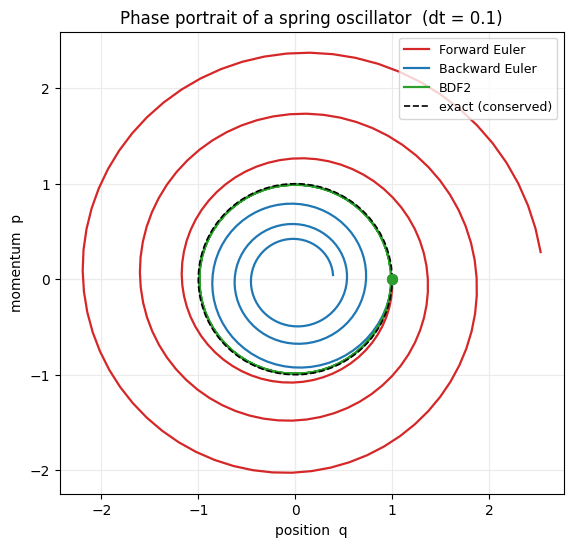

In [5]:
fig, ax = utils.phase_plot({s: traj[s][0] for s in schemes},
                           title=f"Phase portrait of a spring oscillator  (dt = {h})")
theta = np.linspace(0, 2 * np.pi, 200)
ax.plot(np.cos(theta), m * omega * np.sin(theta), "k--", lw=1.2, label="exact (conserved)")
ax.legend(loc="upper right", fontsize=9); plt.show()

Same story as a time series: the total energy each scheme *should* hold flat.

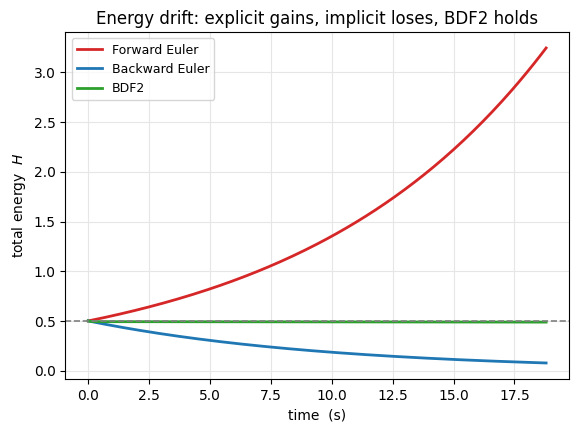

In [6]:
t = np.arange(n_steps + 1) * h
fig, ax = utils.line_plot(t, {s: traj[s][1] for s in schemes},
    xlabel="time  (s)", ylabel="total energy  $H$", colors=utils.INTEGRATOR_COLORS,
    title="Energy drift: explicit gains, implicit loses, BDF2 holds")
ax.axhline(0.5 * k * y0[0] ** 2, color="0.5", ls="--", lw=1.2); plt.show()

And the same three integrators as actual oscillating springs, side by side.


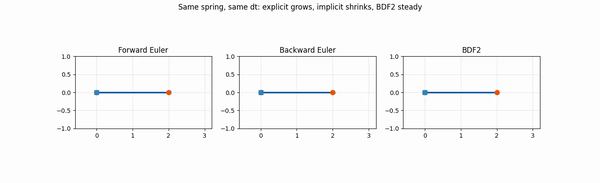

In [7]:
E = np.array([[0, 1]]); stride = max(1, (n_steps + 1) // 90); panels = []
for s in schemes:
    u = traj[s][0][::stride, 0]
    states = [np.array([[0.0, 0.0], [1.0 + ui, 0.0]]) for ui in u]
    panels.append({"states": states, "E": E, "title": s})
fig, anim = utils.animate_springs_grid(panels, lims=((-0.6, 3.2), (-1.0, 1.0)), fps=20,
    pin_pts=np.array([[0.0, 0.0]]),
    suptitle="Same spring, same dt: explicit grows, implicit shrinks, BDF2 steady")
utils.save_anim(anim, "media/11_oscillators.mp4", fps=20)
plt.close(fig); utils.show_anim(anim)

## 3 &middot; A cable: many spring elements glued together

One spring resists only *stretch*. Chain many end to end and pin both ends, and
the assembly behaves like an elastic **cable**: under gravity the interior nodes
drop until tension balances weight (a catenary sag). Pure springs carry no
*bending* stiffness, so this is a cable, not a stiff beam &mdash; bending would be
the next ingredient.

With flattened vertex positions \(x\) the total potential is
$$ \Phi(x) = \underbrace{\textstyle\sum_e \mathrm{vol}_e\,\psi_e(x)}_{\text{elastic}}
   \;-\; \underbrace{f_g^\top x}_{\text{gravity}}
   \;+\; \underbrace{\tfrac12 x^\top Q x + b^\top x}_{\text{pin penalty}}. $$
simkit assembles the elastic term with the edge-displacement operator \(J\)
(so \(d = Jx\) stacks every edge vector) via `mass_springs_*_z`.

* **Without inertia** (quasi-static): the cable sits where \(\Phi\) is
  *minimised*; hand \(\Phi, \nabla\Phi, \nabla^2\Phi\) to Newton.
* **With inertia** (dynamic): each Backward-Euler step minimises
  \(\Phi(x) + \tfrac{1}{2h^2}\lVert x - \tilde x\rVert_M^2\) with momentum
  target \(\tilde x = x_n + h v_n\); the cable overshoots and rings down to the
  *same* equilibrium.

In [8]:
def build_cable(n_nodes=21, length=4.0, ym_val=40.0, rho=1.0):
    """Horizontal chain of springs pinned at both ends; returns the potential."""
    X = np.zeros((n_nodes, 2)); X[:, 0] = np.linspace(0.0, length, n_nodes)
    E = np.array([[i, i + 1] for i in range(n_nodes - 1)])
    n, dim = X.shape
    Be = simkit.edge_displacement_jacobian(X, E)
    J  = sp.sparse.kron(Be, sp.sparse.eye(dim)).tocsc()       # d = J x stacks edge vectors
    l0 = simkit.edge_lengths(X, E).reshape(-1, 1)
    ym = np.full((E.shape[0], 1), ym_val); vol = np.ones((E.shape[0], 1))
    M  = sp.sparse.kron(simkit.massmatrix(X, E, rho=rho), sp.sparse.eye(dim)).tocsc()
    f_g = simkit.gravity_force(X, E, a=-9.8, rho=rho).reshape(-1, 1)
    pin_idx = np.array([0, n_nodes - 1])                      # pin both endpoints
    Q_pin, b_pin = simkit.dirichlet_penalty(pin_idx, X[pin_idx], n, 1e8)

    def energy(x):
        xc = x.reshape(-1, 1)
        return (energies.mass_springs_energy_z(xc, J, ym, vol, l0)
                + 0.5 * (xc.T @ (Q_pin @ xc))[0, 0] + (b_pin.T @ xc)[0, 0]
                - (f_g.T @ xc)[0, 0])
    def gradient(x):
        xc = x.reshape(-1, 1)
        return energies.mass_springs_gradient_z(xc, J, ym, vol, l0) + Q_pin @ xc + b_pin - f_g
    def hessian(x):
        xc = x.reshape(-1, 1)
        return energies.mass_springs_hessian_z(xc, J, ym, vol, l0, psd=True) + Q_pin
    return dict(X=X, E=E, n=n, dim=dim, M=M, pin_idx=pin_idx,
                energy=energy, gradient=gradient, hessian=hessian)

cab = build_cable()
X, E, n, dim = cab["X"], cab["E"], cab["n"], cab["dim"]
energy, gradient, hessian, M = cab["energy"], cab["gradient"], cab["hessian"], cab["M"]

### Without inertia: static equilibrium via Newton

No time, no velocity &mdash; just minimise \(\Phi\). We record every Newton
iterate and watch the flat chain relax into its catenary sag.

static: |grad| = 6.71e-13,  max sag = 0.883



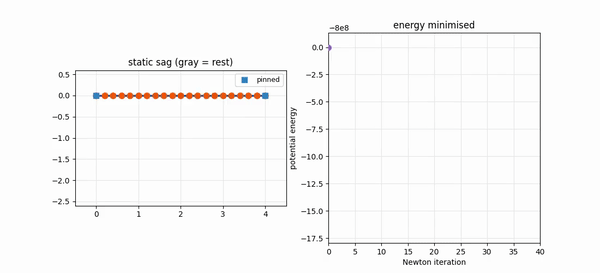

In [9]:
static_states = [X.copy()]
x = X.flatten().astype(float).reshape(-1, 1)
for _ in range(40):
    x = newton_solver(x, energy, gradient, hessian, max_iter=1, do_line_search=True)
    static_states.append(x.reshape(n, dim).copy())
x_static = x.reshape(n, dim)
print(f"static: |grad| = {np.linalg.norm(gradient(x_static)):.2e},  "
      f"max sag = {-(x_static[:,1].min()):.3f}")

fig, anim = utils.animate_springs_energy(
    static_states, E, np.arange(len(static_states)),
    {"potential": [energy(s.flatten()) for s in static_states]}, rest=X,
    lims=((-0.5, 4.5), (-2.6, 0.6)), xlabel="Newton iteration", ylabel="potential energy",
    scene_title="static sag (gray = rest)", title="energy minimised",
    colors={"potential": utils.ENERGY_COLORS["potential"]}, pin_pts=X[cab["pin_idx"]])
utils.save_anim(anim, "media/11_cable_static.mp4", fps=12)
plt.close(fig); utils.show_anim(anim)

### With inertia: Backward-Euler dynamics from rest

Release the flat chain and march it in time. It falls, overshoots, and oscillates
&mdash; the kinetic energy rings down as it settles to the static shape above.

dynamic: settled max sag = 0.893  (matches static),  final KE = 2.98e-04



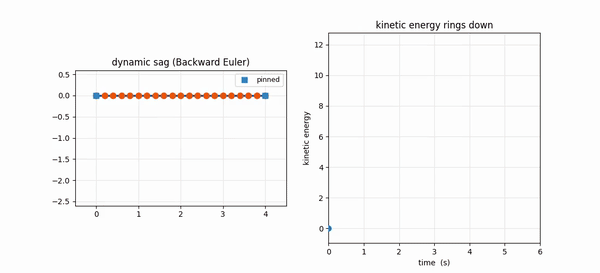

In [10]:
h, n_steps = 0.04, 150
def implicit_step(U, V):
    # backward_euler takes a position history; U - hV is the previous position
    x_next = backward_euler(U.reshape(-1, 1), (U - h * V).reshape(-1, 1),
                            energy, gradient, hessian, M, h,
                            max_iter=20, do_line_search=True).reshape(n, dim)
    return x_next, (x_next - U) / h

U, V = X.copy(), np.zeros_like(X)
dyn_states, ke_hist, t_hist = [U.copy()], [0.0], [0.0]
for step in range(n_steps):
    U, V = implicit_step(U, V); vc = V.reshape(-1, 1)
    dyn_states.append(U.copy()); ke_hist.append(0.5 * (vc.T @ (M @ vc))[0,0]); t_hist.append((step+1)*h)
print(f"dynamic: settled max sag = {-(U[:,1].min()):.3f}  (matches static),  "
      f"final KE = {ke_hist[-1]:.2e}")

fig, anim = utils.animate_springs_energy(
    dyn_states, E, t_hist, {"kinetic": ke_hist}, rest=X, lims=((-0.5, 4.5), (-2.6, 0.6)),
    xlabel="time  (s)", ylabel="kinetic energy", scene_title="dynamic sag (Backward Euler)",
    title="kinetic energy rings down", colors={"kinetic": utils.ENERGY_COLORS["kinetic"]},
    pin_pts=X[cab["pin_idx"]])
utils.save_anim(anim, "media/11_cable_dynamic.mp4", fps=25)
plt.close(fig); utils.show_anim(anim)

### Same equilibrium, two roads

Quasi-static minimisation and full dynamics settle to the **same** sagged shape.


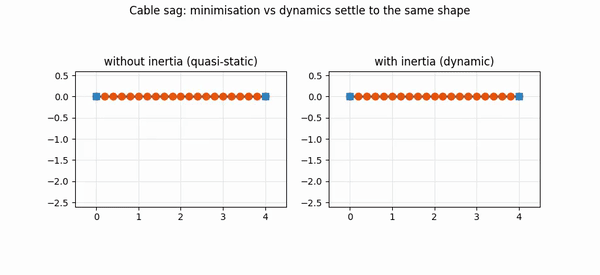

In [11]:
nf = 80
qs  = [static_states[min(int(i/nf*(len(static_states)-1)), len(static_states)-1)] for i in range(nf)]
dyn = [dyn_states[i] for i in np.linspace(0, len(dyn_states) - 1, nf).astype(int)]
fig, anim = utils.animate_springs_grid(
    [{"states": qs,  "E": E, "title": "without inertia (quasi-static)"},
     {"states": dyn, "E": E, "title": "with inertia (dynamic)"}],
    lims=((-0.5, 4.5), (-2.6, 0.6)), fps=25, pin_pts=X[cab["pin_idx"]],
    suptitle="Cable sag: minimisation vs dynamics settle to the same shape")
utils.save_anim(anim, "media/11_cable_compare.mp4", fps=25)
plt.close(fig); utils.show_anim(anim)

Finally, a quick parameter study: softer springs (smaller `ym`) sag more.

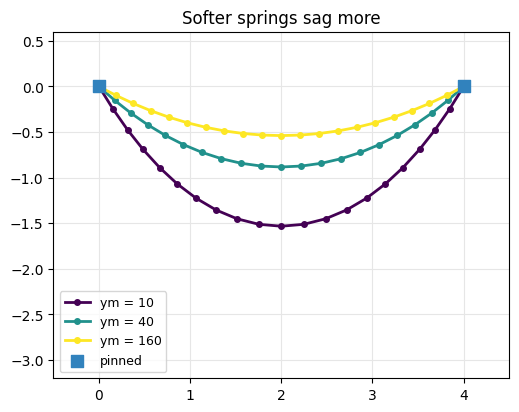

In [12]:
sags = {}
for ym_val in [10.0, 40.0, 160.0]:
    cc = build_cable(ym_val=ym_val)
    xs = newton_solver(cc["X"].flatten().astype(float).reshape(-1, 1), cc["energy"], cc["gradient"], cc["hessian"], max_iter=60, do_line_search=True)
    sags[ym_val] = xs.reshape(cc["n"], cc["dim"])

fig, ax = plt.subplots(figsize=(7, 4.5))
utils.setup_axes(ax, (-0.5, 4.5), (-3.2, 0.6), title="Softer springs sag more")
cmap = plt.get_cmap("viridis")
for j, (ym_val, xs) in enumerate(sags.items()):
    ax.plot(xs[:, 0], xs[:, 1], "-o", ms=4, lw=2,
            color=cmap(j / max(1, len(sags) - 1)), label=f"ym = {ym_val:g}")
ax.scatter(X[cab["pin_idx"], 0], X[cab["pin_idx"], 1], s=70, marker="s",
           color=utils.PIN_C, zorder=5, label="pinned")
ax.legend(fontsize=9); plt.show()

### Takeaways
* A spring stores \(\tfrac12 k (l-l_0)^2\); differentiating gives the linear
  **Hooke force** \(-k(l-l_0)\).
* With inertia the integrator decides the energy behaviour: **Forward Euler**
  gains it (unstable), **Backward Euler** bleeds it (damped), **BDF2** nearly
  conserves it &mdash; vivid in the phase portrait.
* Many springs make an elastic **cable**; gravity sags it into a catenary, and the
  quasi-static minimisation and the dynamic Backward-Euler run settle to the
  **same** equilibrium shape.